# Car Part State Detection (Multi-Label Classification dengan EfficientNet-B0)
## Mata Kuliah Pengantar Deep Learning

---

**Nama** : Rio Ramadhani Harllambang

**NIM** : 1202220205

**Kelas** : SI-46-EDM

---

Deskripsi Proyek :

Notebook ini berisi pipeline pelatihan model deep learning untuk mendeteksi **state (buka/tutup)** dari bagian-bagian mobil secara otomatis menggunakan pendekatan **multi-label image classification**.

Model menerima input berupa gambar mobil 3D dan memprediksi kondisi dari 5 bagian sekaligus:

| Label | Deskripsi |
|---|---|
| `front_left` | Pintu depan kiri (buka/tutup) |
| `front_right` | Pintu depan kanan (buka/tutup) |
| `rear_left` | Pintu belakang kiri (buka/tutup) |
| `rear_right` | Pintu belakang kanan (buka/tutup) |
| `hood` | Kap mesin (buka/tutup) |

---

### Arsitektur Model

Model yang digunakan adalah **EfficientNet-B0** dengan custom classification head:

```
EfficientNet-B0 (Pretrained ImageNet)
        ↓
   Feature Extractor (1280-dim)
        ↓
   Linear(1280 → 256) + BN + ReLU + Dropout(0.4)
        ↓
   Linear(256 → 128) + BN + ReLU + Dropout(0.3)
        ↓
   Linear(128 → 5)
        ↓
   Sigmoid → Multi-label Output
```

**Alasan memilih EfficientNet-B0:**
- Parameter efisien (~5.3M) namun akurasi kompetitif
- Pretrained ImageNet → transfer learning mempercepat konvergensi
- Cocok untuk dataset skala menengah (±2300 gambar)

---

### Dataset

Dataset dikumpulkan secara otomatis menggunakan Selenium dari simulasi 3D mobil BMW X7 dengan variasi:
- **32 kombinasi konfigurasi** pintu & kap (2⁵)
- **24 sudut rotasi horizontal** (setiap 15°)
- **3 level zoom**
- **Total: 2.304 gambar** berukuran 512×512 px

Split dataset:
| Split | Jumlah | Proporsi |
|---|---|---|
| Train | 1.612 | 70% |
| Val | 461 | 20% |
| Test | 231 | 10% |

Distribusi label **seimbang sempurna** (50% open, 50% closed per class) karena data di-generate secara terprogram.

---

### Training Strategy

| Komponen | Detail |
|---|---|
| Loss Function | `BCEWithLogitsLoss` |
| Optimizer | AdamW (lr=1e-4, weight_decay=1e-4) |
| Scheduler | CosineAnnealingLR |
| Early Stopping | Patience = 5 epoch |
| Epochs | Maks 30 |
| Batch Size | 32 |
| Metric Utama | Macro F1-Score |

---

### Augmentasi

Augmentasi diterapkan **hanya pada data train** menggunakan library **Albumentations**:

| Teknik Augmentasi | Status Penggunaan | Alasan |
|---|---|---|
| Resize | Aman | Digunakan untuk menyamakan ukuran input gambar sebelum masuk ke model. |
| ShiftScaleRotate ringan | Aman | Membantu model lebih robust terhadap pergeseran posisi, sedikit perubahan skala, dan rotasi kecil. |
| RandomBrightnessContrast ringan | Aman | Membantu model mengenali objek pada variasi pencahayaan dan kontras. |
| Normalize | Aman | Menyesuaikan distribusi piksel dengan standar input model pretrained seperti ImageNet. |
| ToTensorV2 | Aman | Mengubah gambar menjadi tensor agar dapat diproses oleh PyTorch. |
| Perspective ringan | Cukup aman | Dapat mensimulasikan sedikit perubahan sudut kamera, tetapi tidak boleh terlalu besar agar bentuk mobil tidak terdistorsi. |
| GaussNoise ringan | Cukup aman | Bisa menambah robustness terhadap noise, tetapi harus sangat ringan agar detail pintu dan hood tidak rusak. |
| HueSaturationValue ringan | Cukup aman | Bisa digunakan sedikit untuk variasi warna, tetapi tidak terlalu penting karena dataset berasal dari objek 3D yang relatif konsisten. |
| HorizontalFlip | Tidak aman | Dapat menukar posisi kiri dan kanan mobil sehingga label front_left, front_right, rear_left, dan rear_right menjadi salah jika label tidak ikut ditukar. |
| CoarseDropout | Tidak aman | Dapat menutup bagian penting seperti pintu atau hood yang menjadi target prediksi. |
| MotionBlur berat | Tidak aman | Dapat mengaburkan garis pintu, celah hood, dan detail kecil yang penting untuk klasifikasi. |
| GaussNoise berat | Tidak aman | Noise berlebih dapat merusak detail visual pada pintu dan kap mesin. |
| Perspective berat | Tidak aman | Distorsi besar dapat membuat bentuk mobil tidak natural dan membingungkan model. |
| CLAHE | Kurang disarankan | Dapat mengubah kontras secara tidak natural pada gambar mobil 3D. |

## 1. Install & Import

In [1]:
# !pip install torch torchvision timm albumentations scikit-learn matplotlib seaborn tqdm -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    hamming_loss, classification_report,
    multilabel_confusion_matrix
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cpu


## 2. Config

In [2]:
# ==================================================
# CONFIG
# ==================================================

DATA_DIR    = "dataset_split"
TRAIN_DIR   = os.path.join(DATA_DIR, "train")
VAL_DIR     = os.path.join(DATA_DIR, "val")
TEST_DIR    = os.path.join(DATA_DIR, "test")

LABEL_COLS  = ["front_left", "front_right", "rear_left", "rear_right", "hood"]
NUM_CLASSES = len(LABEL_COLS)
IMG_SIZE    = 224

BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-4
PATIENCE    = 5       # early stopping

THRESHOLD   = 0.5    # default, nanti di-tune

CHECKPOINT  = "best_model.pth"

## 3. Dataset & Augmentasi

In [3]:
# ==================================================
# AUGMENTASI TRAIN — AMAN & TERKONTROL
# ==================================================

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=8,
        border_mode=cv2.BORDER_CONSTANT,
        value=(32, 32, 32),
        p=0.35
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.30
    ),

    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    ToTensorV2()
])

# ==================================================
# TRANSFORM VALIDATION / TEST — TANPA AUGMENTASI
# ==================================================

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    ToTensorV2()
])

class CarPartDataset(Dataset):

    def __init__(self, split_dir, label_cols, transform=None):
        self.img_dir    = os.path.join(split_dir, "images")
        self.df         = pd.read_csv(os.path.join(split_dir, "labels.csv"))
        self.label_cols = label_cols
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        path   = os.path.join(self.img_dir, row["image"])
        img    = np.array(Image.open(path).convert("RGB"))
        labels = torch.tensor(
            row[self.label_cols].values.astype(np.float32)
        )

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, labels


train_ds = CarPartDataset(TRAIN_DIR, LABEL_COLS, train_transform)
val_ds   = CarPartDataset(VAL_DIR,   LABEL_COLS, val_transform)
test_ds  = CarPartDataset(TEST_DIR,  LABEL_COLS, val_transform)

PIN_MEMORY = False  # CPU mode

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}")

Train : 1612 | Val : 461 | Test : 231


c:\Users\Acer NITRO 5\Documents\Tubes Deep Learning\venv\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Acer NITRO 5\AppData\Local\Temp\ipykernel_30140\1687647199.py:8: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(


## 4. Model

In [4]:
class CarPartClassifier(nn.Module):

    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=pretrained,
            num_classes=0  # hapus head bawaan
        )

        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


model        = CarPartClassifier(NUM_CLASSES).to(DEVICE)
optimizer    = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
best_val_f1  = 0.0
patience_cnt = 0
history      = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
print(model)
print(f"\nTotal params : {sum(p.numel() for p in model.parameters()):,}")

CarPartClassifier(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
      

## 5. Loss, Optimizer, Scheduler

In [5]:
# Label seimbang (50:50), pos_weight = 1.0 semua
pos_weight = torch.ones(NUM_CLASSES).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

## 6. Training Loop

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    loop = tqdm(loader, leave=False, desc="Training")
    for imgs, labels in loop:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > THRESHOLD).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

        loop.set_postfix(loss=f"{loss.item():.4f}")

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return total_loss / len(loader), f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        loop = tqdm(loader, leave=False, desc="Evaluating")
        for imgs, labels in loop:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(logits) > THRESHOLD).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return total_loss / len(loader), f1


# ==================================================
# TRAINING
# ==================================================

history = {
    "train_loss": [], "val_loss": [],
    "train_f1":   [], "val_f1":   []
}

best_val_f1  = 0.0
patience_cnt = 0

epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epoch", unit="epoch")

for epoch in epoch_bar:

    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_f1   = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    epoch_bar.set_postfix({
        "TrLoss" : f"{train_loss:.4f}",
        "TrF1"   : f"{train_f1:.4f}",
        "ValLoss": f"{val_loss:.4f}",
        "ValF1"  : f"{val_f1:.4f}",
    })

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f}  Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f}  Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_cnt = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f"✓ Best model saved (Val F1: {best_val_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"⏹ Early stopping at epoch {epoch}")
            break

Epoch:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training:   0%|          | 0/51 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [01/30] Train Loss: 0.7035  Train F1: 0.5103 | Val Loss: 0.6628  Val F1: 0.5686
✓ Best model saved (Val F1: 0.5686)


Training:   0%|          | 0/51 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [29/30] Train Loss: 0.1689  Train F1: 0.9872 | Val Loss: 0.1358  Val F1: 0.9991


Training:   0%|          | 0/51 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [30/30] Train Loss: 0.1673  Train F1: 0.9847 | Val Loss: 0.1374  Val F1: 0.9991


## 7. Plot Training Curve

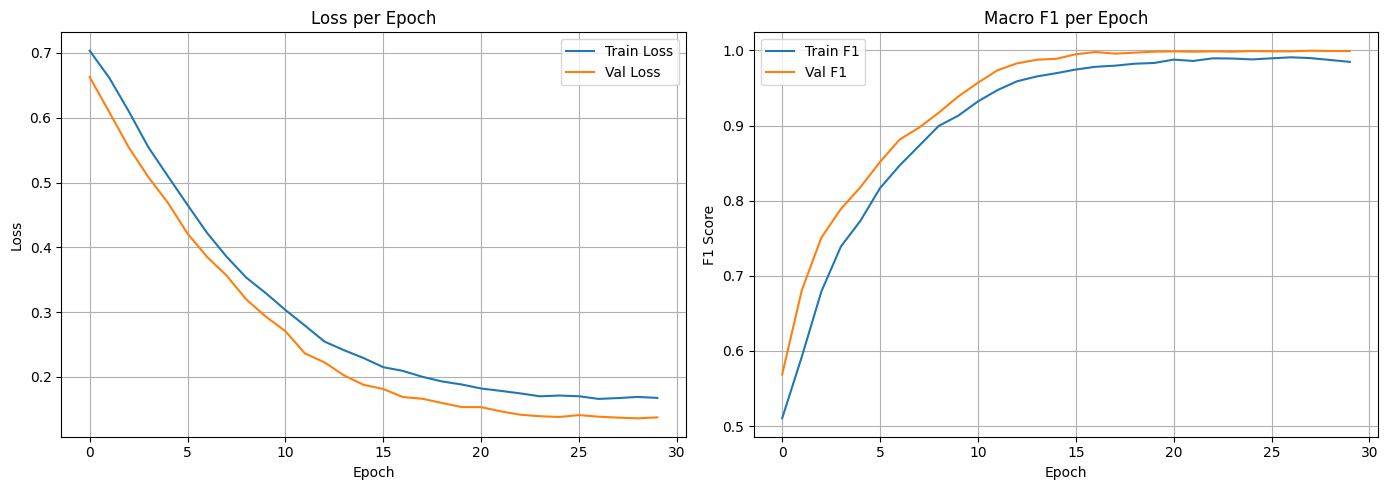

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_f1"], label="Train F1")
axes[1].plot(history["val_f1"],   label="Val F1")
axes[1].set_title("Macro F1 per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()

## 8. Evaluasi Test Set

In [13]:
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.to(DEVICE)
model.eval()

all_probs, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)

        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

# Prediksi dengan threshold default 0.5 untuk semua label
THRESHOLD = 0.5
all_preds = (all_probs > THRESHOLD).astype(int)

# Metrik
print("=" * 50)
print("EVALUASI TEST SET")
print("=" * 50)
print(f"Hamming Loss   : {hamming_loss(all_labels, all_preds):.4f}")
print(f"Macro F1       : {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
print(f"Micro F1       : {f1_score(all_labels, all_preds, average='micro', zero_division=0):.4f}")
print(f"Macro Precision: {precision_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
print(f"Macro Recall   : {recall_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")

print("\nPer-class Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=LABEL_COLS,
    zero_division=0
))

EVALUASI TEST SET
Hamming Loss   : 0.0017
Macro F1       : 0.9983
Micro F1       : 0.9983
Macro Precision: 0.9967
Macro Recall   : 1.0000

Per-class Report:
              precision    recall  f1-score   support

  front_left       1.00      1.00      1.00       115
 front_right       1.00      1.00      1.00       114
   rear_left       1.00      1.00      1.00       114
  rear_right       0.98      1.00      0.99       118
        hood       1.00      1.00      1.00       118

   micro avg       1.00      1.00      1.00       579
   macro avg       1.00      1.00      1.00       579
weighted avg       1.00      1.00      1.00       579
 samples avg       0.97      0.97      0.97       579



## 9. Confusion Matrix per Class

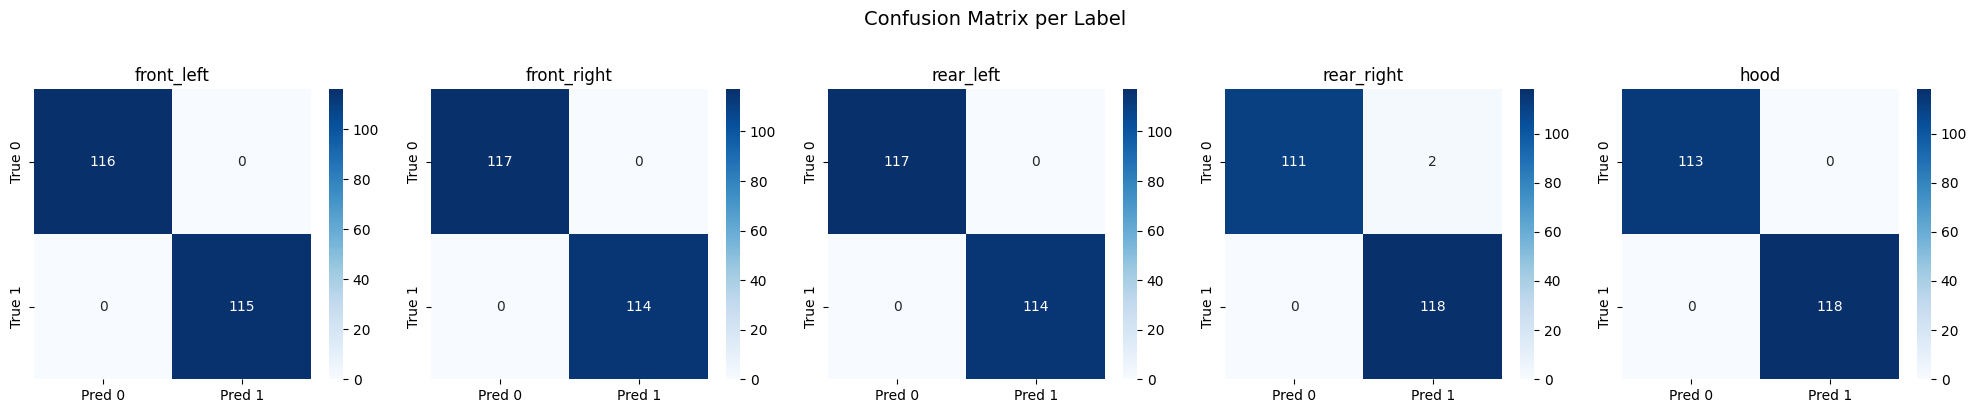

In [10]:
mcm = multilabel_confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))

for i, (ax, label) in enumerate(zip(axes, LABEL_COLS)):
    cm = mcm[i]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
        ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Confusion Matrix per Label", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Visualisasi Prediksi Sampel

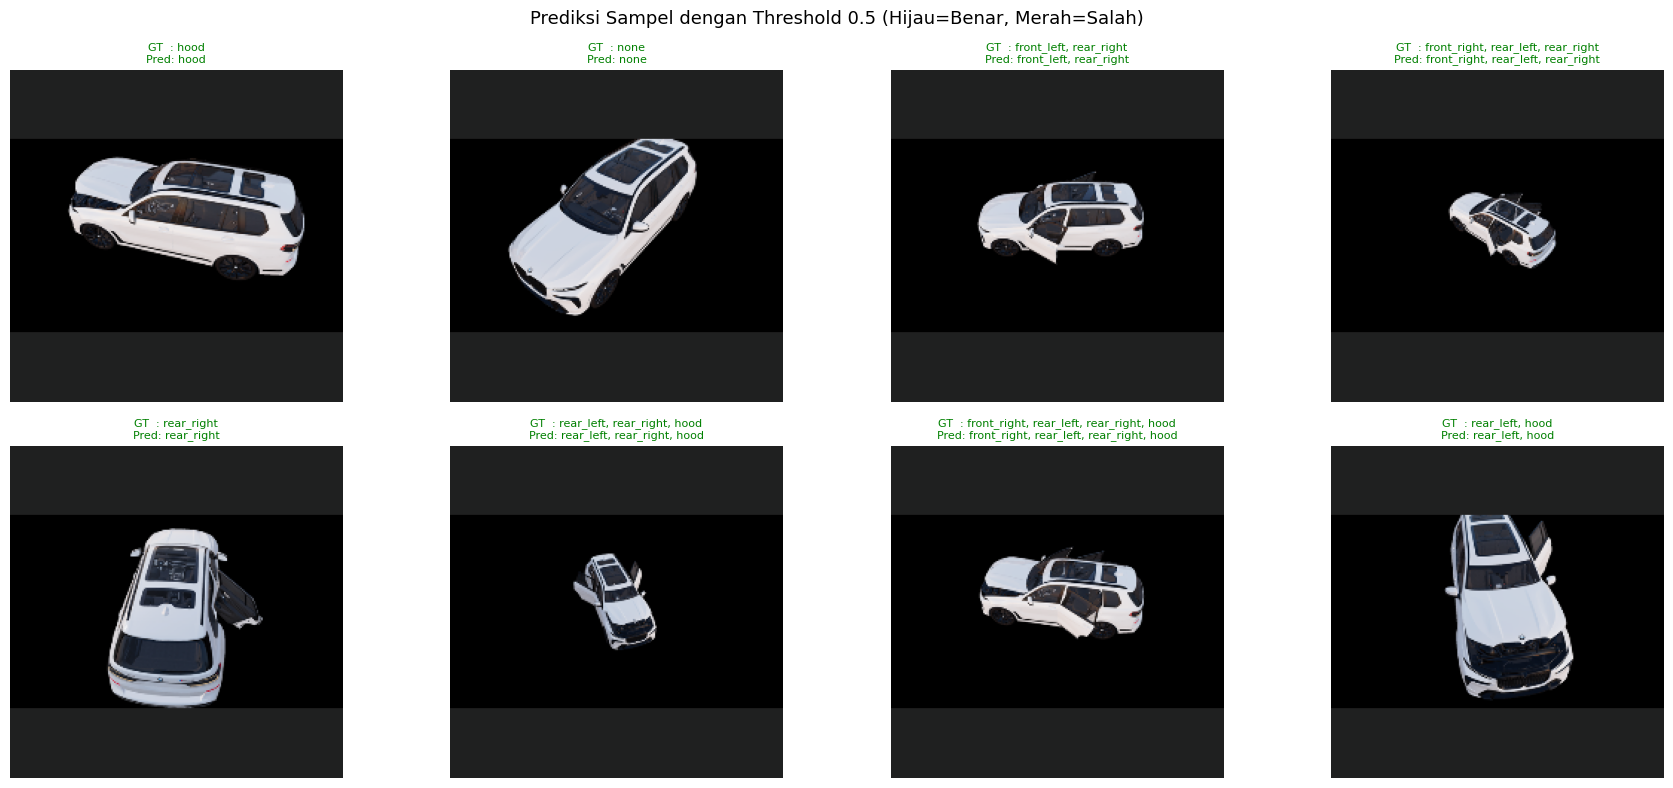

In [14]:
model.eval()

# Ambil 1 batch dari test
imgs_batch, labels_batch = next(iter(test_loader))
imgs_tensor = imgs_batch.to(DEVICE)

with torch.no_grad():
    logits = model(imgs_tensor)
    probs  = torch.sigmoid(logits).cpu().numpy()

# Prediksi dengan threshold default 0.5 untuk semua label
THRESHOLD = 0.5
preds = (probs > THRESHOLD).astype(int)

# Denormalize untuk display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

n_show = 8
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        break

    img = imgs_batch[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)

    gt   = labels_batch[i].numpy().astype(int)
    pred = preds[i]

    gt_labels   = [LABEL_COLS[j] for j in range(NUM_CLASSES) if gt[j] == 1]
    pred_labels = [LABEL_COLS[j] for j in range(NUM_CLASSES) if pred[j] == 1]

    gt_str   = ", ".join(gt_labels) if gt_labels else "none"
    pred_str = ", ".join(pred_labels) if pred_labels else "none"

    color = "green" if np.array_equal(gt, pred) else "red"

    ax.imshow(img)
    ax.set_title(
        f"GT  : {gt_str}\nPred: {pred_str}",
        fontsize=8,
        color=color
    )
    ax.axis("off")

plt.suptitle("Prediksi Sampel dengan Threshold 0.5 (Hijau=Benar, Merah=Salah)", fontsize=13)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()

## 11. Export CSV Classification Report

In [12]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import pandas as pd
import json

report = classification_report(
    all_labels,
    all_preds,
    target_names=LABEL_COLS,
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("classification_report.csv")

overall_metrics = {
    "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
    "micro_f1": f1_score(all_labels, all_preds, average="micro", zero_division=0),
    "macro_precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
    "macro_recall": recall_score(all_labels, all_preds, average="macro", zero_division=0)
}

with open("overall_metrics.json", "w") as f:
    json.dump(overall_metrics, f, indent=4)